Why the all platforms is not being used


In [2]:
import pandas as pd

DATA_PATH = "/content/Video Game Sales 1978 - 2024 export 2025-12-20 22-38-27.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (63927, 16)


,Rank,Name,Platform,All_Platforms,All_Games,Publisher,Developer,Critic_Score,User_Score,NA_Sales,PAL_Sales,JP_Sales,Other_Sales,Global_Sales,Year,Genre
0,1,Tetris,Series,NaN,Tetris (1984)|Tetris (1989)|Welltris|Hatris|Tw...,The Tetris Company,Alexey Pajitnov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1988.0,Puzzle
1,2,Pokemon,Series,NaN,Pokemon Red & Green (Japan-only) & Blue|Pokemo...,Nintendo,Game Freak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998.0,Role-Playing
2,3,Call of Duty,Series,NaN,Call of Duty|Call of Duty 2|Call of Duty 3|Cal...,Activision,Infinity Ward,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.0,Shooter
3,4,Grand Theft Auto,Series,NaN,Grand Theft Auto|Grand Theft Auto: London 1969...,Rockstar Games,Rockstar North,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998.0,Action-Adventure
4,5,Super Mario,Series,NaN,Mario Bros.|Super Mario Bros.|Super Mario Bros...,Nintendo,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1983.0,Platform


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63927 entries, 0 to 63926
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           63927 non-null  int64  
 1   Name           63927 non-null  object 
 2   Platform       63927 non-null  object 
 3   All_Platforms  1101 non-null   object 
 4   All_Games      441 non-null    object 
 5   Publisher      63927 non-null  object 
 6   Developer      63927 non-null  object 
 7   Critic_Score   6601 non-null   float64
 8   User_Score     414 non-null    float64
 9   NA_Sales       13656 non-null  float64
 10  PAL_Sales      14019 non-null  float64
 11  JP_Sales       7673 non-null   float64
 12  Other_Sales    16364 non-null  float64
 13  Global_Sales   20301 non-null  float64
 14  Year           57062 non-null  float64
 15  Genre          63927 non-null  object 
dtypes: float64(8), int64(1), object(7)
memory usage: 7.8+ MB


In [4]:
df["All_Platforms"].value_counts(dropna=False).head(30)


,count
All_Platforms,
NaN,62826
PC & Mac,81
PC|PS4|Xbox One,58
PC|PS4|Xbox One|Switch,36
PC|PS3|Xbox 360,36
PS3 & Xbox 360,26
PC|PS4|Switch,14
PC|PS2|Xbox,12
PC & PS4,9


In [5]:
df["Platform"].value_counts(dropna=False).head(30)


,count
Platform,
PC,12577
PS2,3565
DS,3288
PS4,2869
PS,2707
NS,2331
XBL,2121
PSN,2005
XOne,1951


Spark Implementation

In [6]:
!pip install pyspark


In [7]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("VideoGameSalesLakehouse")
    .getOrCreate()
)

spark.version


'4.0.1'

In [8]:
print("Spark session started successfully on Google Colab.")


Spark session started successfully on Google Colab.


BRONZE LAYER – INGESTION


In [9]:

DATA_PATH = "/content/Video Game Sales 1978 - 2024 export 2025-12-20 22-38-27.csv"
BRONZE_PATH = "/content/lakehouse/bronze/video_game_sales"

# Check file
import os
print("File exists:", os.path.exists(DATA_PATH))

# Read raw CSV
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df_raw.printSchema()
df_raw.show(5)
print("Total records:", df_raw.count())

# Write Bronze layer
(
    df_raw
    .write
    .mode("overwrite")
    .parquet(BRONZE_PATH)
)

print("Bronze layer written to:", BRONZE_PATH)


File exists: True
root
 |-- Rank: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Platform: string (nullable = true)
 |-- All_Platforms: string (nullable = true)
 |-- All_Games: string (nullable = true)
 |-- Publisher: string (nullable = true)
 |-- Developer: string (nullable = true)
 |-- Critic_Score: double (nullable = true)
 |-- User_Score: double (nullable = true)
 |-- NA_Sales: double (nullable = true)
 |-- PAL_Sales: double (nullable = true)
 |-- JP_Sales: double (nullable = true)
 |-- Other_Sales: double (nullable = true)
 |-- Global_Sales: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Genre: string (nullable = true)

+----+----------------+--------+-------------+--------------------+--------------------+-----------------+------------+----------+--------+---------+--------+-----------+------------+----+----------------+
|Rank|            Name|Platform|All_Platforms|           All_Games|           Publisher|        Developer|Critic_Score|Us

SILVER LAYER – CLEANING

In [10]:


from pyspark.sql.functions import col, coalesce, lit, trim, length, when

BRONZE_PATH = "/content/lakehouse/bronze/video_game_sales"
SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

df_bronze = spark.read.parquet(BRONZE_PATH)

df_silver = (
    df_bronze
    .dropna(subset=["Year", "Global_Sales"])
    .withColumn("Year", col("Year").cast("int"))
    .withColumn("Global_Sales", col("Global_Sales").cast("double"))
    .withColumn("NA_Sales", coalesce(col("NA_Sales").cast("double"), lit(0.0)))
    .withColumn("PAL_Sales", coalesce(col("PAL_Sales").cast("double"), lit(0.0)))
    .withColumn("JP_Sales", coalesce(col("JP_Sales").cast("double"), lit(0.0)))
    .withColumn("Other_Sales", coalesce(col("Other_Sales").cast("double"), lit(0.0)))
    .dropDuplicates()
    .withColumn(
        "All_Platforms_Normalized",
        when(
            col("All_Platforms").isNull() |
            (length(trim(col("All_Platforms"))) == 0),
            lit("Unknown_Platform")
        ).otherwise(trim(col("All_Platforms")))
    )
)

df_silver.write.mode("overwrite").parquet(SILVER_PATH)
print("Silver layer written:", SILVER_PATH)


Silver layer written: /content/lakehouse/silver/video_game_sales


GOLD – SALES BY YEAR


In [11]:


from pyspark.sql.functions import sum as spark_sum

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"
GOLD_YEAR_PATH = "/content/lakehouse/gold/sales_by_year"

df_silver = spark.read.parquet(SILVER_PATH)

df_sales_by_year = (
    df_silver
    .groupBy("Year")
    .agg(
        spark_sum("Global_Sales").alias("Total_Global_Sales")
    )
    .orderBy("Year")
)

df_sales_by_year.show(10)

(
    df_sales_by_year
    .write
    .mode("overwrite")
    .parquet(GOLD_YEAR_PATH)
)

print("Gold sales_by_year written")


+----+------------------+
|Year|Total_Global_Sales|
+----+------------------+
|1970|              1.16|
|1977|               2.5|
|1978|6.1899999999999995|
|1979|              0.31|
|1980|              2.58|
|1981|10.489999999999998|
|1982| 43.50000000000001|
|1983|             24.82|
|1984| 7.819999999999999|
|1985|             93.72|
+----+------------------+
only showing top 10 rows
Gold sales_by_year written


GOLD – SALES BY PRIMARY PLATFORM


In [12]:

from pyspark.sql.functions import col

GOLD_PLATFORM_PATH = "/content/lakehouse/gold/sales_by_platform"

df_sales_by_platform = (
    df_silver
    .groupBy("Platform")
    .agg(
        spark_sum("Global_Sales").alias("Total_Global_Sales")
    )
    .orderBy(col("Total_Global_Sales").desc())
)

df_sales_by_platform.show(10)

(
    df_sales_by_platform
    .write
    .mode("overwrite")
    .parquet(GOLD_PLATFORM_PATH)
)

print("Gold sales_by_platform written")


+--------+------------------+
|Platform|Total_Global_Sales|
+--------+------------------+
|     PS2| 1261.339999999997|
|    X360|  985.309999999999|
|     PS3| 958.6699999999989|
|     Wii| 915.0099999999991|
|      DS| 804.6999999999987|
|      PS| 734.4399999999996|
|     PS4| 651.9099999999996|
|     GBA|            323.98|
|     3DS| 318.3299999999999|
|     PSP| 301.4000000000003|
+--------+------------------+
only showing top 10 rows
Gold sales_by_platform written


GOLD – SALES BY GENRE


In [13]:


GOLD_GENRE_PATH = "/content/lakehouse/gold/sales_by_genre"

df_sales_by_genre = (
    df_silver
    .groupBy("Genre")
    .agg(
        spark_sum("Global_Sales").alias("Total_Global_Sales")
    )
    .orderBy(col("Total_Global_Sales").desc())
)

df_sales_by_genre.show(10)

(
    df_sales_by_genre
    .write
    .mode("overwrite")
    .parquet(GOLD_GENRE_PATH)
)

print("Gold sales_by_genre written")


+------------+------------------+
|       Genre|Total_Global_Sales|
+------------+------------------+
|      Sports|1464.7599999999952|
|      Action|1351.4699999999955|
|     Shooter|1199.4599999999984|
|Role-Playing|1012.7799999999988|
|    Platform| 913.8899999999996|
|        Misc| 798.6099999999979|
|      Racing| 787.1499999999995|
|    Fighting| 494.1700000000001|
|   Adventure|465.04000000000036|
|  Simulation| 414.6500000000003|
+------------+------------------+
only showing top 10 rows
Gold sales_by_genre written


GOLD – SALES BY REGION


In [14]:

GOLD_REGION_PATH = "/content/lakehouse/gold/sales_by_region"

df_sales_by_region = df_silver.select(
    spark_sum("NA_Sales").alias("NA_Sales"),
    spark_sum("PAL_Sales").alias("PAL_Sales"),
    spark_sum("JP_Sales").alias("JP_Sales"),
    spark_sum("Other_Sales").alias("Other_Sales")
)

df_sales_by_region.show()

(
    df_sales_by_region
    .write
    .mode("overwrite")
    .parquet(GOLD_REGION_PATH)
)

print("Gold sales_by_region written")


+-----------------+-----------------+-----------------+-----------------+
|         NA_Sales|        PAL_Sales|         JP_Sales|      Other_Sales|
+-----------------+-----------------+-----------------+-----------------+
|4710.479999999954|2695.769999999906|1389.729999999974|874.1799999999675|
+-----------------+-----------------+-----------------+-----------------+

Gold sales_by_region written


# VALIDATION & DATA QUALITY


In [15]:

from pyspark.sql.functions import col

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

GOLD_YEAR_PATH = "/content/lakehouse/gold/sales_by_year"
GOLD_PLATFORM_PATH = "/content/lakehouse/gold/sales_by_platform"
GOLD_GENRE_PATH = "/content/lakehouse/gold/sales_by_genre"
GOLD_REGION_PATH = "/content/lakehouse/gold/sales_by_region"

# Load datasets
df_silver = spark.read.parquet(SILVER_PATH)
df_year = spark.read.parquet(GOLD_YEAR_PATH)
df_platform = spark.read.parquet(GOLD_PLATFORM_PATH)
df_genre = spark.read.parquet(GOLD_GENRE_PATH)
df_region = spark.read.parquet(GOLD_REGION_PATH)


In [14]:
invalid_years = df_silver.filter(
    (col("Year").isNotNull()) &
    ((col("Year") < 1978) | (col("Year") > 2024))
)

print("Invalid year records:", invalid_years.count())

# Soft validation (log, don't fail)
invalid_years.show(5)


Invalid year records: 13
+-----+--------------------+--------+-------------+---------+-----------+--------------------+------------+----------+--------+---------+--------+-----------+------------+----+------------+------------------------+
| Rank|                Name|Platform|All_Platforms|All_Games|  Publisher|           Developer|Critic_Score|User_Score|NA_Sales|PAL_Sales|JP_Sales|Other_Sales|Global_Sales|Year|       Genre|All_Platforms_Normalized|
+-----+--------------------+--------+-------------+---------+-----------+--------------------+------------+----------+--------+---------+--------+-----------+------------+----+------------+------------------------+
|21889|          Deep Black|      PC|         NULL|     NULL|505 Games  |     BiArt Studios  |        NULL|      NULL|     0.0|      0.0|     0.0|        0.0|        0.01|1970|     Shooter|        Unknown_Platform|
|17711|      Check vs. Mate|     PS3|         NULL|     NULL|  Unknown  |TopWare Interacti...|        NULL|      NU

In [16]:
negative_sales = df_silver.filter(
    (col("Global_Sales") < 0) |
    (col("NA_Sales") < 0) |
    (col("PAL_Sales") < 0) |
    (col("JP_Sales") < 0) |
    (col("Other_Sales") < 0)
)

print("Negative sales records:", negative_sales.count())
assert negative_sales.count() == 0


Negative sales records: 0


In [17]:
from pyspark.sql.functions import abs as spark_abs

# Allow small rounding differences (0.05 million units)
tolerance = 0.05

inconsistent_sales = df_silver.filter(
    (col("NA_Sales") + col("PAL_Sales") + col("JP_Sales") + col("Other_Sales"))
    > (col("Global_Sales") + tolerance)
)

print("Inconsistent regional sales records (beyond tolerance):", inconsistent_sales.count())

inconsistent_sales.show(5)


Inconsistent regional sales records (beyond tolerance): 0
+----+----+--------+-------------+---------+---------+---------+------------+----------+--------+---------+--------+-----------+------------+----+-----+------------------------+
|Rank|Name|Platform|All_Platforms|All_Games|Publisher|Developer|Critic_Score|User_Score|NA_Sales|PAL_Sales|JP_Sales|Other_Sales|Global_Sales|Year|Genre|All_Platforms_Normalized|
+----+----+--------+-------------+---------+---------+---------+------------+----------+--------+---------+--------+-----------+------------+----+-----+------------------------+
+----+----+--------+-------------+---------+---------+---------+------------+----------+--------+---------+--------+-----------+------------+----+-----+------------------------+



In [18]:
print("Gold sales by year rows:", df_year.count())
print("Gold sales by platform rows:", df_platform.count())
print("Gold sales by genre rows:", df_genre.count())
print("Gold sales by region rows:", df_region.count())
print("Gold sales by region rows:", df_region.count())


assert df_year.count() > 0
assert df_platform.count() > 0
assert df_genre.count() > 0
assert df_region.count() > 0


Gold sales by year rows: 45
Gold sales by platform rows: 39
Gold sales by genre rows: 20
Gold sales by region rows: 1
Gold sales by region rows: 1


# VISUALIZATION – SALES OVER TIME


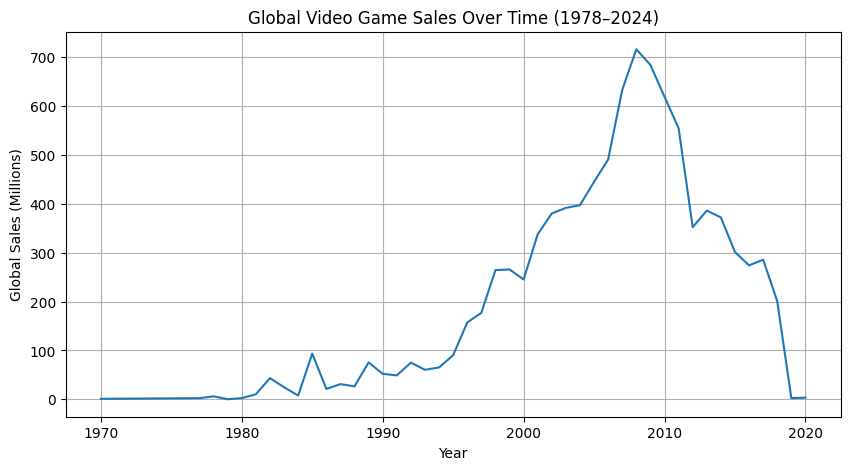

In [19]:


import matplotlib.pyplot as plt

GOLD_YEAR_PATH = "/content/lakehouse/gold/sales_by_year"

df_year = spark.read.parquet(GOLD_YEAR_PATH)
pdf_year = df_year.toPandas()

plt.figure(figsize=(10,5))
plt.plot(pdf_year["Year"], pdf_year["Total_Global_Sales"])
plt.title("Global Video Game Sales Over Time (1978–2024)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(True)
plt.show()


# VISUALIZATION – TOP PLATFORMS


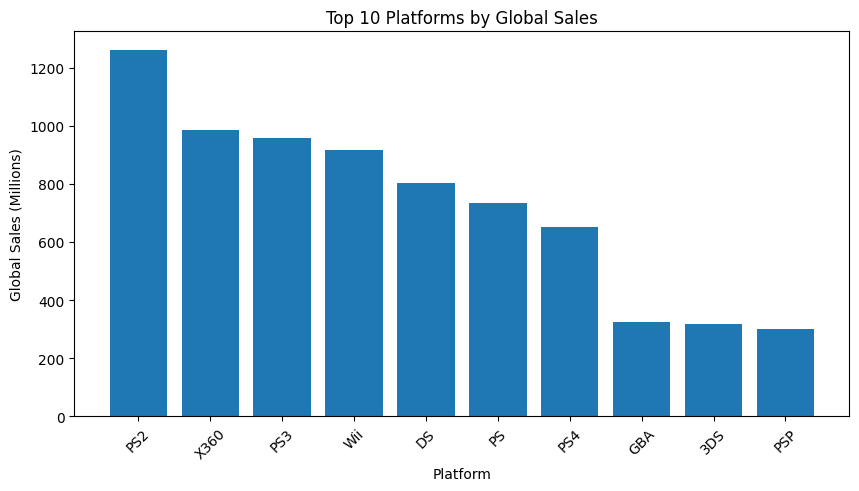

In [20]:


GOLD_PLATFORM_PATH = "/content/lakehouse/gold/sales_by_platform"

df_platform = spark.read.parquet(GOLD_PLATFORM_PATH)
pdf_platform = df_platform.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf_platform["Platform"], pdf_platform["Total_Global_Sales"])
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()


# VISUALIZATION – SALES BY GENRE


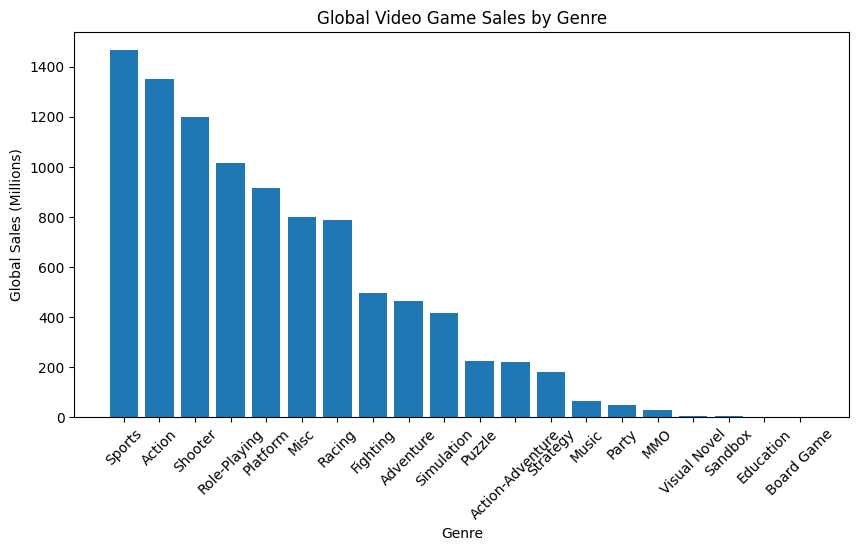

In [21]:


GOLD_GENRE_PATH = "/content/lakehouse/gold/sales_by_genre"

df_genre = spark.read.parquet(GOLD_GENRE_PATH)
pdf_genre = df_genre.toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf_genre["Genre"], pdf_genre["Total_Global_Sales"])
plt.title("Global Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()


# VISUALIZATION – SALES BY REGION



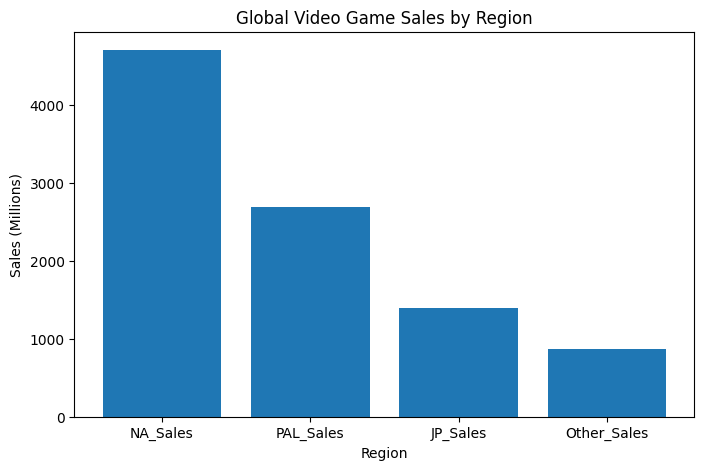

In [22]:


import pandas as pd

GOLD_REGION_PATH = "/content/lakehouse/gold/sales_by_region"

df_region = spark.read.parquet(GOLD_REGION_PATH)
pdf_region = df_region.toPandas()

# Convert from wide to long format
pdf_region_long = pdf_region.melt(
    var_name="Region",
    value_name="Total_Sales"
)

plt.figure(figsize=(8,5))
plt.bar(pdf_region_long["Region"], pdf_region_long["Total_Sales"])
plt.title("Global Video Game Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (Millions)")
plt.show()


# VISUALIZATION – SALES OVER TIME BY PLATFORM


+----+--------+-------------------+
|Year|Platform| Total_Global_Sales|
+----+--------+-------------------+
|1970|      PC|               0.46|
|1970|     PS3|               0.04|
|1970|     PSP|0.44999999999999996|
|1970|    2600|               0.21|
|1977|    2600|                2.5|
+----+--------+-------------------+
only showing top 5 rows
Top platforms: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']


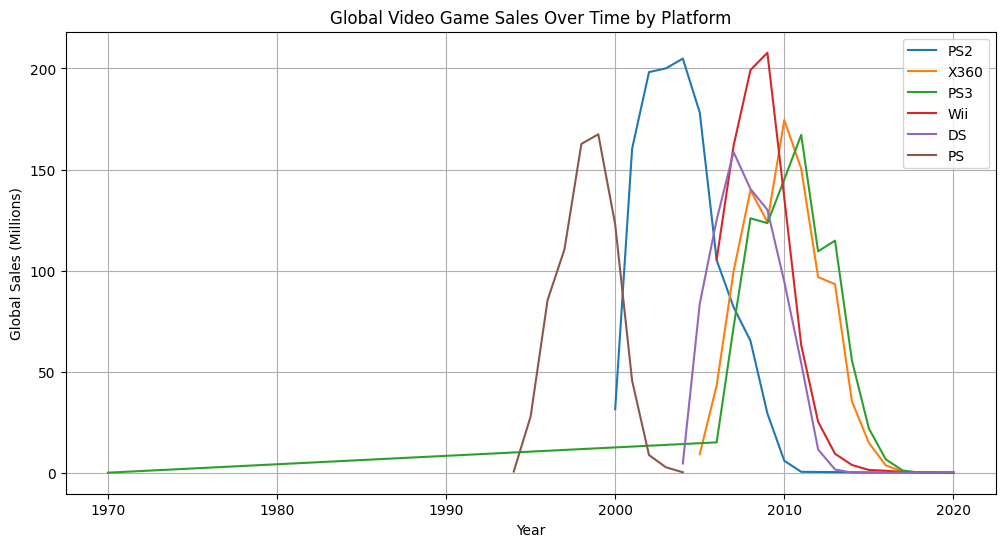

In [23]:


from pyspark.sql.functions import sum as spark_sum
import matplotlib.pyplot as plt

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

df_silver = spark.read.parquet(SILVER_PATH)

# Aggregate sales by Year and Platform
df_year_platform = (
    df_silver
    .groupBy("Year", "Platform")
    .agg(
        spark_sum("Global_Sales").alias("Total_Global_Sales")
    )
    .orderBy("Year")
)

df_year_platform.show(5)

# Get top 6 platforms by total sales
top_platforms = (
    df_silver
    .groupBy("Platform")
    .agg(spark_sum("Global_Sales").alias("Total"))
    .orderBy("Total", ascending=False)
    .limit(6)
    .select("Platform")
    .toPandas()["Platform"]
    .tolist()
)

print("Top platforms:", top_platforms)

# Filter Spark data to top platforms only
df_year_platform_top = df_year_platform.filter(
    df_year_platform.Platform.isin(top_platforms)
)

pdf_year_platform = df_year_platform_top.toPandas()

plt.figure(figsize=(12,6))

for platform in top_platforms:
    platform_data = pdf_year_platform[pdf_year_platform["Platform"] == platform]
    plt.plot(
        platform_data["Year"],
        platform_data["Total_Global_Sales"],
        label=platform
    )

plt.title("Global Video Game Sales Over Time by Platform")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend()
plt.grid(True)
plt.show()


+----+-----------------+-------------------+
|Year|Platform_Category|              Sales|
+----+-----------------+-------------------+
|1970|               PC|               0.46|
|1970|          Console|0.48999999999999994|
|1970|            Other|               0.21|
|1977|            Other|                2.5|
|1978|            Other| 6.1899999999999995|
+----+-----------------+-------------------+
only showing top 5 rows


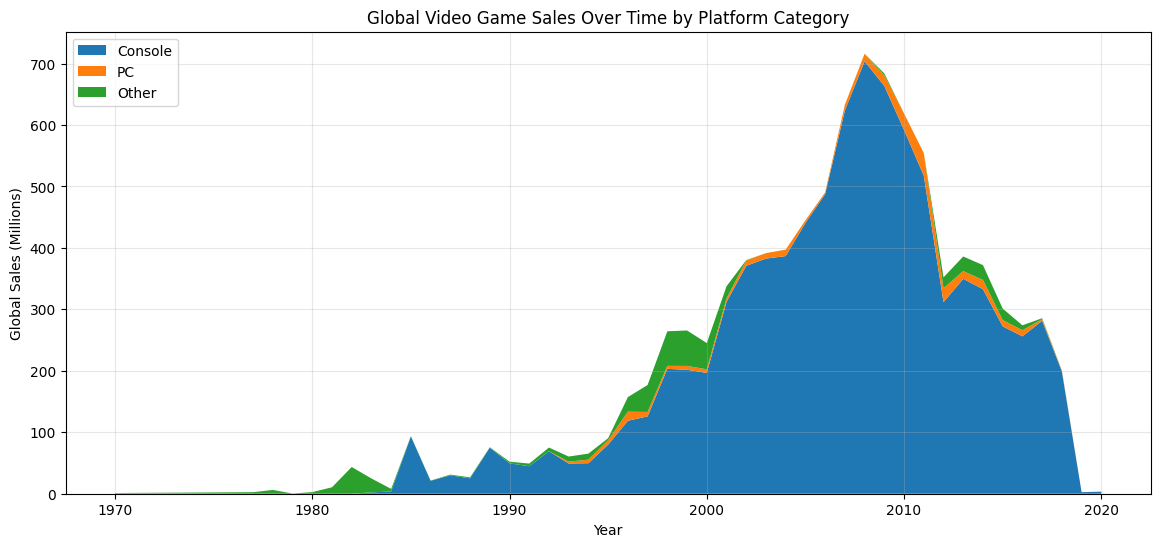

In [25]:
from pyspark.sql.functions import when, col, sum as spark_sum

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

df = spark.read.parquet(SILVER_PATH)

console_platforms = [
    "PS", "PS2", "PS3", "PS4", "PS5", "PSP", "PSV",
    "XB", "XBL", "X360", "XOne",
    "Wii", "DS", "3DS", "GBA", "GB", "NES", "SNES",
    "GC", "VC", "SAT", "DC", "NS"
]

pc_platforms = ["PC", "OSX"]

df_cat = (
    df.withColumn(
        "Platform_Category",
        when(col("Platform").isin(pc_platforms), "PC")
        .when(col("Platform").isin(console_platforms), "Console")
        .otherwise("Other")
    )
)

df_year_cat = (
    df_cat
    .groupBy("Year", "Platform_Category")
    .agg(spark_sum("Global_Sales").alias("Sales"))
    .orderBy("Year")
)

df_year_cat.show(5)

import matplotlib.pyplot as plt

pdf = df_year_cat.toPandas()

pivot = (
    pdf
    .pivot(index="Year", columns="Platform_Category", values="Sales")
    .fillna(0)
    .sort_index()
)

pivot.head()

plt.figure(figsize=(14,6))

plt.stackplot(
    pivot.index,
    pivot.get("Console", 0),
    pivot.get("PC", 0),
    pivot.get("Other", 0),
    labels=["Console", "PC", "Other"]
)

plt.title("Global Video Game Sales Over Time by Platform Category")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)

plt.show()

+----+------------+------------------+----+
|Year|       Genre|       Total_Sales|rank|
+----+------------+------------------+----+
|1970|Role-Playing|              0.63|   1|
|1977|      Action|              1.25|   1|
|1978|     Shooter|              2.53|   1|
|1979|      Action|              0.31|   1|
|1980|    Fighting|              1.24|   1|
|1981|     Shooter|              8.12|   1|
|1982|      Action|14.450000000000003|   1|
|1983|    Platform|7.3100000000000005|   1|
|1984|      Action|2.6300000000000003|   1|
|1985|    Platform|             42.25|   1|
+----+------------+------------------+----+
only showing top 10 rows


/tmp/ipython-input-3608802471.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(genres))


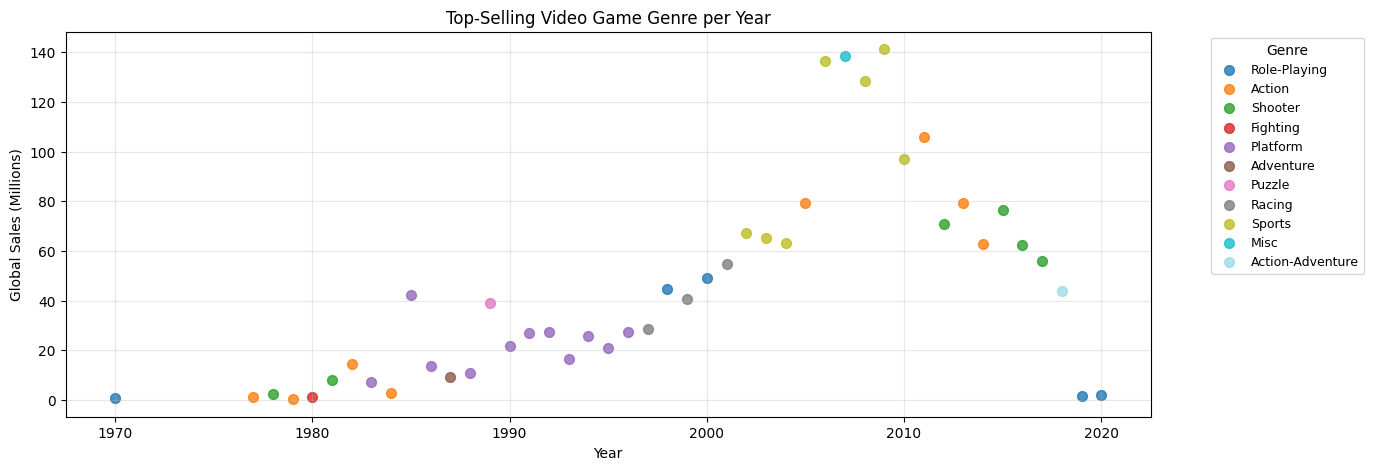

In [26]:
from pyspark.sql.functions import sum as spark_sum, col, row_number
from pyspark.sql.window import Window

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

df = spark.read.parquet(SILVER_PATH)

# Aggregate sales by Year & Genre
df_year_genre = (
    df.groupBy("Year", "Genre")
    .agg(spark_sum("Global_Sales").alias("Total_Sales"))
)

# Window to rank genres per year
window_genre = Window.partitionBy("Year").orderBy(col("Total_Sales").desc())

df_top_genre = (
    df_year_genre
    .withColumn("rank", row_number().over(window_genre))
    .filter(col("rank") == 1)
    .orderBy("Year")
)

df_top_genre.show(10)

pdf_genre = df_top_genre.toPandas()

genres = pdf_genre["Genre"].unique()

# Generate a color for each genre dynamically
cmap = plt.cm.get_cmap("tab20", len(genres))
color_map = {genre: cmap(i) for i, genre in enumerate(genres)}

plt.figure(figsize=(14,5))

for genre in genres:
    subset = pdf_genre[pdf_genre["Genre"] == genre]
    plt.scatter(
        subset["Year"],
        subset["Total_Sales"],
        label=genre,
        color=color_map[genre],
        s=50,
        alpha=0.8
    )

plt.title("Top-Selling Video Game Genre per Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend(
    title="Genre",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)
plt.grid(alpha=0.3)

plt.show()


In [40]:
# Aggregate sales by Year & Platform
df_year_platform = (
    df.groupBy("Year", "Platform")
    .agg(spark_sum("Global_Sales").alias("Total_Sales"))
)

# Window to rank platforms per year
window_platform = Window.partitionBy("Year").orderBy(col("Total_Sales").desc())

df_top_platform = (
    df_year_platform
    .withColumn("rank", row_number().over(window_platform))
    .filter(col("rank") == 1)
    .orderBy("Year")
)

df_top_platform.show(10)


+----+--------+------------------+----+
|Year|Platform|       Total_Sales|rank|
+----+--------+------------------+----+
|1970|      PC|              0.46|   1|
|1977|    2600|               2.5|   1|
|1978|    2600|6.1899999999999995|   1|
|1979|    2600|              0.31|   1|
|1980|    2600|              2.58|   1|
|1981|    2600|10.489999999999998|   1|
|1982|    2600| 43.50000000000001|   1|
|1983|    2600|             22.68|   1|
|1984|    2600|              4.16|   1|
|1985|     NES|             93.27|   1|
+----+--------+------------------+----+
only showing top 10 rows


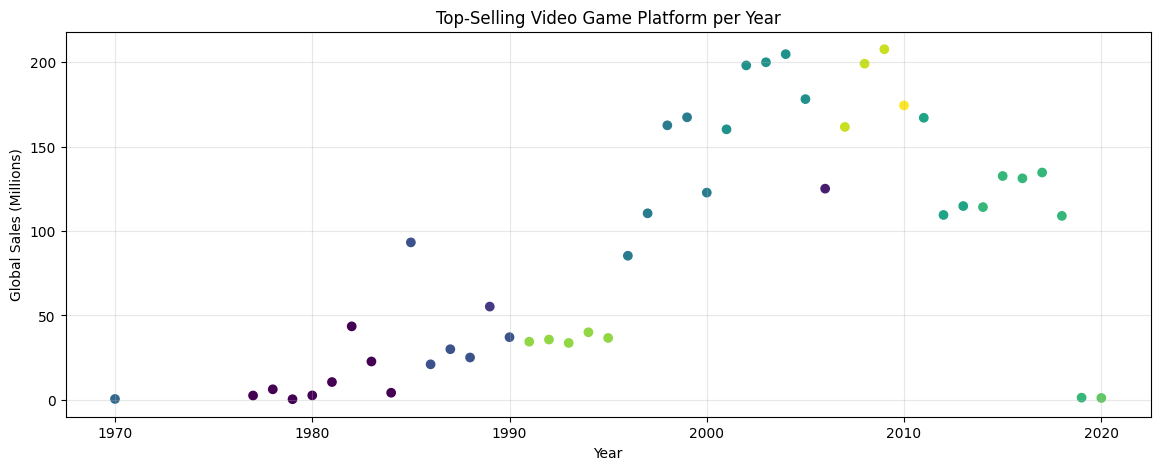

In [41]:
pdf_platform = df_top_platform.toPandas()

plt.figure(figsize=(14,5))
plt.scatter(
    pdf_platform["Year"],
    pdf_platform["Total_Sales"],
    c=pdf_platform["Platform"].astype("category").cat.codes
)

plt.title("Top-Selling Video Game Platform per Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(alpha=0.3)
plt.show()


In [30]:
from pyspark.sql.functions import count, col

SILVER_PATH = "/content/lakehouse/silver/video_game_sales"

df = spark.read.parquet(SILVER_PATH)

# Count number of games per Year & Genre
df_year_genre_count = (
    df.groupBy("Year", "Genre")
    .agg(count("*").alias("Releases"))
    .orderBy("Year")
)

df_year_genre_count.show(5)

+----+---------+--------+
|Year|    Genre|Releases|
+----+---------+--------+
|1970|     Misc|       1|
|1970|Adventure|       2|
|1970|  Shooter|       1|
|1970| Strategy|       1|
|1970|   Sports|       1|
+----+---------+--------+
only showing top 5 rows


In [31]:
import matplotlib.pyplot as plt

pdf_genre = df_year_genre_count.toPandas()

pivot_genre = (
    pdf_genre
    .pivot(index="Year", columns="Genre", values="Releases")
    .fillna(0)
    .sort_index()
)

pivot_genre.head()


Genre,Action,Action-Adventure,Adventure,Board Game,Education,Fighting,MMO,Misc,Music,Party,Platform,Puzzle,Racing,Role-Playing,Sandbox,Shooter,Simulation,Sports,Strategy,Visual Novel
Year,,,,,,,,,,,,,,,,,,,,
1970,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0
1977,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1978,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1979,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


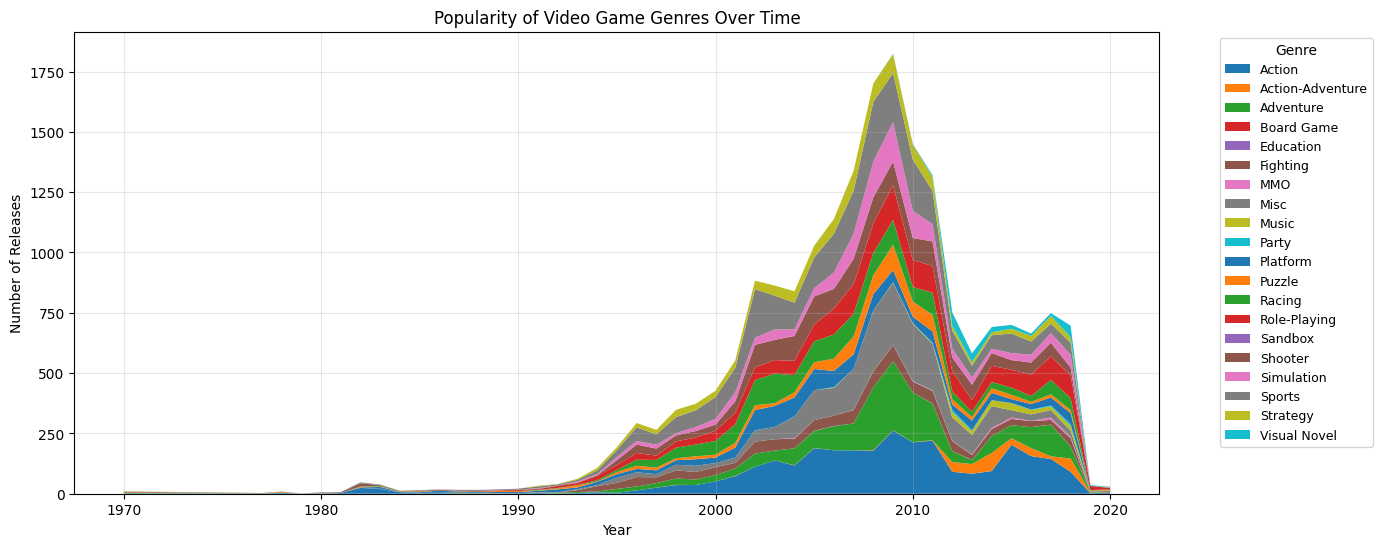

In [32]:
plt.figure(figsize=(14,6))

plt.stackplot(
    pivot_genre.index,
    pivot_genre.T.values,
    labels=pivot_genre.columns
)

plt.title("Popularity of Video Game Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.legend(
    title="Genre",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)
plt.grid(alpha=0.3)
plt.show()

In [33]:
from pyspark.sql.functions import desc

# Top 10 platforms by number of releases
top_platforms = (
    df.groupBy("Platform")
    .agg(count("*").alias("Total_Releases"))
    .orderBy(desc("Total_Releases"))
    .limit(10)
    .select("Platform")
)

top_platforms_list = [row["Platform"] for row in top_platforms.collect()]
print(top_platforms_list)


['DS', 'PS2', 'PC', 'Wii', 'PS3', 'PSP', 'X360', 'PS', 'PS4', 'GBA']


In [34]:
df_year_platform_count = (
    df.filter(col("Platform").isin(top_platforms_list))
    .groupBy("Year", "Platform")
    .agg(count("*").alias("Releases"))
    .orderBy("Year")
)

df_year_platform_count.show(5)


+----+--------+--------+
|Year|Platform|Releases|
+----+--------+--------+
|1970|      PC|       6|
|1970|     PS3|       1|
|1970|     PSP|       2|
|1986|      PC|       1|
|1989|      PC|       1|
+----+--------+--------+
only showing top 5 rows


In [35]:
pdf_platform = df_year_platform_count.toPandas()

pivot_platform = (
    pdf_platform
    .pivot(index="Year", columns="Platform", values="Releases")
    .fillna(0)
    .sort_index()
)

pivot_platform.head()


Platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
Year,,,,,,,,,,
1970,0.0,0.0,6.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
1986,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1989,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1993,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994,0.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
pdf_platform = df_year_platform_count.toPandas()

pivot_platform = (
    pdf_platform
    .pivot(index="Year", columns="Platform", values="Releases")
    .fillna(0)
    .sort_index()
)

pivot_platform.head()


Platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
Year,,,,,,,,,,
1970,0.0,0.0,6.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
1986,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1989,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1993,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994,0.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0


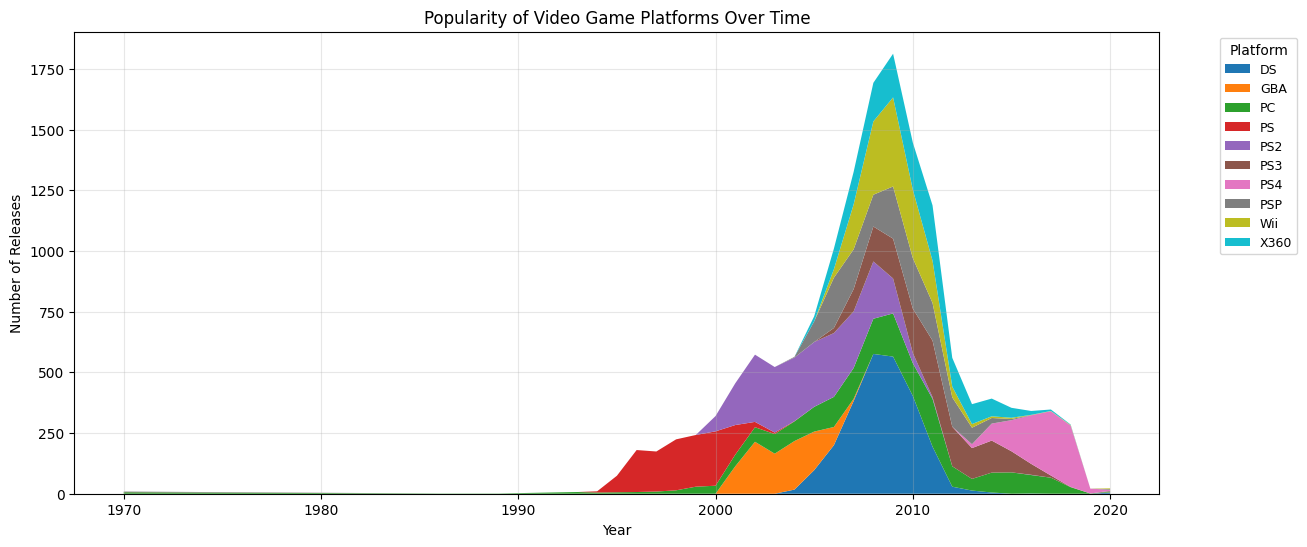

In [37]:
plt.figure(figsize=(14,6))

plt.stackplot(
    pivot_platform.index,
    pivot_platform.T.values,
    labels=pivot_platform.columns
)

plt.title("Popularity of Video Game Platforms Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.legend(
    title="Platform",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)
plt.grid(alpha=0.3)
plt.show()
